# gMLP MPP — Local Test Run

Small model for quick local validation that the full pipeline works.
- Tiny embed_size (32), 1 gMLP layer
- Pre-collated batches (batch=32, repeat=2) — same pipeline as main training
- Few epochs
- Verifies: dataset → collator → pre-collation → model → trainer → metrics

In [1]:
import sys
from pathlib import Path

ROOT = Path(".").resolve()
if ROOT.name == "gMLP":
    ROOT = ROOT.parent.parent
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)
print("ROOT:", ROOT)

Device: cpu
ROOT: D:\ML_skoltech\ML_project\ML_project-football-


## 1. Data & Vocab

In [2]:
from data.preprocessing import preprocess_raw_csv, build_vocab_mappings

raw_path = ROOT / "dataset" / "data_with_dates.csv"
sample_path = ROOT / "notebooks" / "train_sample_raw.csv"
output_dir = str(ROOT / "notebooks" / "train_sample_processed")

df_raw = pd.read_csv(raw_path)
df_raw.to_csv(sample_path, index=False)
df = preprocess_raw_csv(str(sample_path), output_dir)
vocab = build_vocab_mappings(df, output_dir)

print(f"Matches: {df['match_id'].nunique()}")
print(f"players_vocab_size (pad_idx): {vocab['player_pad_token_id']}")
print(f"MPP classes (real players): {vocab['player_pad_token_id'] - 1}")

Matches: 2923
players_vocab_size (pad_idx): 6394
MPP classes (real players): 6393


## 2. gMLP Dataset & Pre-collated Batches

In [3]:
from torch.utils.data import DataLoader
from data.dataset import MatchDatasetGMLP_MPP, PreCollatedDataset
from data.collator import DataCollatorMPP
try:
    from data.collator import DataCollatorPreCollated
except ImportError:
    from torch.utils.data.dataloader import default_collate
    class DataCollatorPreCollated:
        def __call__(self, batch):
            return default_collate(batch)

sample_batch_size = 32
repeat = 2
dev_ratio = 0.05
seed = 42

ds_full = MatchDatasetGMLP_MPP(
    df,
    player_name2id=vocab["player_name2id"],
    team_name2id=vocab["team_name2id"],
    player_pad_token_id=vocab["player_pad_token_id"],
    team_pad_token_id=vocab["team_pad_token_id"],
    position_pad_token_id=25,
)

# Sanity check
sample = ds_full[0]
print(f"Seq length: {sample['input_ids'].shape[0]}")
print(f"Occupied slots: {sample['attention_mask'].sum().item()}")

collator = DataCollatorMPP(
    player_mask_token_id=vocab["player_mask_token_id"],
    mask_percentage=0.25,
)

def _collate_filter_none(batch):
    batch = [b for b in batch if b is not None]
    return collator(batch) if batch else None

dataloader_build = DataLoader(
    ds_full, batch_size=sample_batch_size, shuffle=True,
    collate_fn=_collate_filter_none, drop_last=True,
)

all_batches = []
for _ in range(repeat):
    for batch in dataloader_build:
        if batch is not None:
            all_batches.append(batch)

np.random.seed(seed)
n_batches = len(all_batches)
dev_size = max(1, int(n_batches * dev_ratio))
dev_idx = np.random.choice(n_batches, size=dev_size, replace=False)
train_idx = [i for i in range(n_batches) if i not in dev_idx]

train_batches = [all_batches[i] for i in train_idx]
dev_batches = [all_batches[i] for i in dev_idx]

train_dataset = PreCollatedDataset(train_batches)
eval_dataset = PreCollatedDataset(dev_batches)
collator_for_trainer = DataCollatorPreCollated()

print(f"Batches: {n_batches}, train: {len(train_batches)}, eval: {len(dev_batches)}")

Seq length: 50
Occupied slots: 22
Batches: 182, train: 173, eval: 9


## 3. Tiny gMLP Model & Trainer

In [5]:
from models.gmlp.pretrain import gMLPMaskedPlayerModel
from training.trainer import build_training_args, build_trainer
from training.metrics import compute_metrics_mpp

# Tiny model for local testing
model = gMLPMaskedPlayerModel(
    embed_size=32,
    num_layers=1,
    d_ffn=128,
    dropout=0.05,
    form_stats_size=39,
    players_vocab_size=vocab["player_pad_token_id"],
    teams_vocab_size=vocab["team_pad_token_id"],
    use_teams_embeddings=False,
    seq_len=50,
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
enc_params = sum(p.numel() for p in model.encoder.parameters())
print(f"Total params: {total_params:,}")
print(f"Encoder params: {enc_params:,}")

output_dir = str(ROOT / "notebooks" / "gMLP" / "test_output")
training_config = {
    "output_dir": output_dir,
    "num_train_epochs": 5,
    "per_device_train_batch_size": 1,
    "per_device_eval_batch_size": 1,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "warmup_ratio": 0.0,
    "lr_scheduler_type": "linear",
    "logging_steps": 20,
    "eval_strategy": "steps",
    "eval_steps": 20,
    "save_strategy": "no",
    "report_to": "none",
    "seed": seed,
}

train_args = build_training_args(training_config)
trainer = build_trainer(
    model=model,
    args=train_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_mpp,
    data_collator=collator_for_trainer,
)
print("Trainer ready.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Total params: 425,935
Encoder params: 214,966
Trainer ready.


## 4. Train

In [6]:
trainer.train()

d:\ML_skoltech\ML_project\ML_project-football-\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy Top1,Accuracy Top3
20,8.778074,8.730378,0.000000,0.000579
40,8.662818,8.584362,0.002315,0.002894
60,8.487883,8.417996,0.002315,0.012153
80,8.362138,8.295016,0.009838,0.018519
100,8.257491,8.214560,0.009838,0.021412
120,8.194764,8.164412,0.009838,0.020833
140,8.145216,8.138003,0.009838,0.019676
160,8.147051,8.111396,0.009838,0.019676
180,8.071664,8.091869,0.009838,0.020255
200,7.910071,8.098309,0.012731,0.023148


TrainOutput(global_step=865, training_loss=7.627268443906927, metrics={'train_runtime': 89.8873, 'train_samples_per_second': 9.623, 'train_steps_per_second': 9.623, 'total_flos': 0.0, 'train_loss': 7.627268443906927, 'epoch': 5.0})

## 5. Evaluate

In [7]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)
results = trainer.evaluate()
print("Eval results:")
for k, v in results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Eval results:
  eval_loss: 7.3830
  eval_accuracy_top1: 0.0330
  eval_accuracy_top3: 0.0509
  eval_runtime: 0.8402
  eval_samples_per_second: 10.7110
  eval_steps_per_second: 10.7110
  epoch: 5.0000


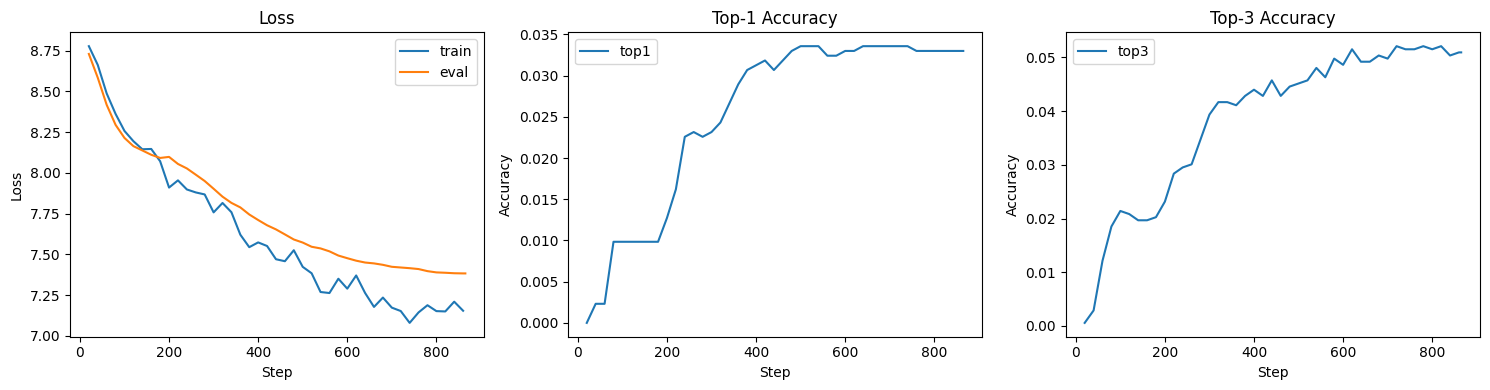

In [8]:
# Plot training loss from log history
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)
train_logs = history[history["loss"].notna()]
eval_logs = history[history["eval_loss"].notna()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_logs["step"], train_logs["loss"], label="train")
if len(eval_logs) > 0:
    axes[0].plot(eval_logs["step"], eval_logs["eval_loss"], label="eval")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

if "eval_accuracy_top1" in eval_logs.columns:
    axes[1].plot(eval_logs["step"], eval_logs["eval_accuracy_top1"], label="top1")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Top-1 Accuracy")
    axes[1].legend()

if "eval_accuracy_top3" in eval_logs.columns:
    axes[2].plot(eval_logs["step"], eval_logs["eval_accuracy_top3"], label="top3")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Accuracy")
    axes[2].set_title("Top-3 Accuracy")
    axes[2].legend()

plt.tight_layout()
plt.show()